# 1. Подготовка окружения | Запуск Experiment_1_2

In [7]:
import os
import json
from tqdm import tqdm

import numpy as np
import pandas as pd
import json

import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.base import BaseEstimator, RegressorMixin

from src import (
    MomentumTransformer2D,
    LegendreTransformer2D,
    FourierTransformer2D,
    ZernikeTransformer2D,
    import_df
)

In [8]:
# Install and setup seaborn for publication-quality plots
!pip install seaborn -q
import seaborn as sns
import matplotlib.pyplot as plt
# Set seaborn style suitable for paper/poster/presentation
sns.set_style("whitegrid")
# Set context for appropriate font size: paper, notebook, talk, poster
sns.set_context("paper")
# Set Times New Roman font for ALL text (including legend, ticks, labels)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Use regular font for math text (so it matches Times New Roman)
plt.rcParams['mathtext.default'] = 'regular'
# Also set legend font explicitly
plt.rcParams['legend.fontsize'] = 'medium'
plt.rcParams['legend.title_fontsize'] = 'medium'


In [ ]:
torch.cuda.is_available()

In [2]:
RESULTS_PATH = "results/Experiment_1_2.json"
BASELINE_PATH = "results/Baseline_1_3.json"
CACHE_DIR = "cache_features"

VAL_RATIO = 2 / 7
TOL = 1e-4
N_ITER_NO_CHANGE = 100
MAX_EPOCHS = 5000

# 2. Загрузка данных и нормировка X
Загружаем Y из Y_ions.csv
Загружаем X (карты ФЛ) через функцию import_df
Формируем массив X размера (N, H, W)
Проверяем согласованность индексов

In [ ]:
def load_results():
    if os.path.exists(RESULTS_PATH):
        with open(RESULTS_PATH, "r") as f:
            return json.load(f)
    return {}

def save_results(results):
    dir_path = os.path.dirname(RESULTS_PATH)

    if dir_path:  # ✅ только если путь не пустой
        os.makedirs(dir_path, exist_ok=True)

    with open(RESULTS_PATH, "w") as f:
        json.dump(results, f)

def ensure_structure(results, model_name, mom):
    if model_name not in results:
        results[model_name] = {}
    if mom not in results[model_name]:
        results[model_name][mom] = {}

In [ ]:
os.makedirs(CACHE_DIR, exist_ok=True)

def get_cache_path(model_name, mom, order, fold_id):
    return os.path.join(CACHE_DIR, f"{mom}_order{order}_fold{fold_id}.npz")


def load_cached_features(mom, order, fold_id):
    path = get_cache_path("", mom, order, fold_id)
    if os.path.exists(path):
        data = np.load(path)
        return data["X_train"], data["X_test"]
    return None


def save_cached_features(mom, order, fold_id, X_train_tr, X_test_tr):
    path = get_cache_path("", mom, order, fold_id)
    np.savez(path, X_train=X_train_tr, X_test=X_test_tr)

In [ ]:
# Y
annotations_file = 'CD_HM_dataset/Y_ions.csv'
y_df = pd.read_csv(annotations_file, index_col='num')

# X
X_list = []
for i in tqdm(range(1, len(y_df)+1)):
    df = import_df(str(i)+'.csv')
    df = df.fillna(0)
    X_list.append(df.values)

X = np.array(X_list)
y = y_df.values

print(X.shape, y.shape)

In [ ]:
# df.values.shape, df.values

In [ ]:
X_max = X.max()
X = X / X_max

# 3. Определение трансформеров (базисов)
Параметры:
* варьируем order
* x_bounds/y_bounds фиксированы (кроме Zernike — задаем явно)

In [ ]:
def get_transformer(name, order, x_bounds=(375, 575), y_bounds=(280, 410)):
    if name == "momentum":
        return MomentumTransformer2D(order=order)
    elif name == "legendre":
        return LegendreTransformer2D(order=order)
    elif name == "fourier":
        return FourierTransformer2D(order=order)
    elif name == "zernike":
        return ZernikeTransformer2D(
            order=order,
            x_bounds=x_bounds,
            y_bounds=y_bounds
        )

# 4. Подготовка моделей
Параметры:

* единый validation split (где возможно)
* фиксированные random_state

In [ ]:
def get_model(name):
    if name == "LR":
        return LinearRegression()

    elif name == "RF":
        # ограничиваем сложность вместо early stopping
        return RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            n_jobs=-1,
            random_state=42,
        )

    elif name == "GB":
        return XGBRegressor(
            n_estimators=1000,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            n_jobs=-1,
            random_state=42,
            early_stopping_rounds=N_ITER_NO_CHANGE,
            eval_metric="rmse"
        )

    elif name == "MLP":
        return MLPRegressor(
            hidden_layer_sizes=(64, 32, 16),
            activation='logistic',
            max_iter=MAX_EPOCHS,
            early_stopping=True,
            validation_fraction=VAL_RATIO,
            n_iter_no_change=N_ITER_NO_CHANGE,
            tol=TOL,
            random_state=42,
            verbose=True
        )

## Реализация CNN-бейзлайна

Создаем класс CNNRegressor:

* наследуем BaseEstimator, RegressorMixin
* используем torch
* реализуем:
    * init
    * fit (с early stopping)
    * predict
* вход: (N, H, W) → reshape в (N, 1, H, W)

In [ ]:
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 3, kernel_size=5, stride=5),
            nn.LeakyReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(3 * 20 * 2, 32),
            nn.LeakyReLU(),
            nn.Linear(32, 1) 
        )

    def forward(self, x):
        return self.net(x)


class CNNRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, epochs=200, lr=1e-3, tol=1e-4, n_iter_no_change=10):
        self.epochs = epochs
        self.lr = lr
        self.tol = tol
        self.n_iter_no_change = n_iter_no_change

    def fit(self, X, y):
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=VAL_RATIO, random_state=42
        )

        X_train = torch.tensor(X_train[:, None, :, :], dtype=torch.float32)
        y_train = torch.tensor(y_train, dtype=torch.float32)

        X_val = torch.tensor(X_val[:, None, :, :], dtype=torch.float32)
        y_val = torch.tensor(y_val, dtype=torch.float32)

        self.model = CNNModel()
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        loss_fn = nn.MSELoss()

        best_loss = np.inf
        patience = 0

        for epoch in range(self.epochs):
            # TRAIN
            self.model.train()
            optimizer.zero_grad()
            preds = self.model(X_train)
            loss = loss_fn(preds, y_train)
            loss.backward()
            optimizer.step()

            # VALIDATION
            self.model.eval()
            with torch.no_grad():
                val_preds = self.model(X_val)
                val_loss = loss_fn(val_preds, y_val).item()

            # EARLY STOPPING
            if best_loss - val_loss > self.tol:
                best_loss = val_loss
                patience = 0
                best_state = self.model.state_dict()
            else:
                patience += 1

            if patience >= self.n_iter_no_change:
                break

        # restore best model
        self.model.load_state_dict(best_state)

        return self

    def predict(self, X):
        X = torch.tensor(X[:, None, :, :], dtype=torch.float32)
        self.model.eval()
        with torch.no_grad():
            return self.model(X).numpy()

# 5. Реализация пайплайна
Для каждой комбинации:

* модель
* базис
* порядок (order)

Реализовано вычисление моментов для всей БД X и их сохранение для экономии вычислительного ресурса.

In [ ]:
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
    rmse = np.sqrt(mean_squared_error(y_true, y_pred, multioutput='raw_values'))
    r2 = r2_score(y_true, y_pred, multioutput='raw_values')
    return mae, rmse, r2

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import callback

kf = KFold(n_splits=10, shuffle=True, random_state=42)

models = ["LR", "RF", "GB", "MLP"]
momenta = ["momentum", "legendre", "fourier", "zernike"]
ions = ["Cu", "Ni", "Pb", "Al", "Co", "Cr", "NO3"]

results = load_results()

for model_name in tqdm(models, desc="Models"):
    
    for mom in tqdm(momenta, desc=f"{model_name} | momenta"):#, leave=False
        
        ensure_structure(results, model_name, mom)

        max_order = 13 if mom != "fourier" else 7

        for order in tqdm(range(max_order + 1), desc=f"{mom} orders"):# , leave=False

            # 👉 заранее создаём структуру для ионов
            for ion in ions:
                if ion not in results[model_name][mom]:
                    results[model_name][mom][ion] = {}

            for fold_id, (train_idx, test_idx) in enumerate(kf.split(X)):

                # ===== проверка кэша =====
                cached = load_cached_features(mom, order, fold_id)

                if cached is not None:
                    X_train_tr, X_test_tr = cached
                else:
                    transformer = get_transformer(mom, order)

                    X_train, X_test = X[train_idx], X[test_idx]

                    transformer.fit(X_train)
                    X_train_tr = transformer.transform(X_train)
                    X_test_tr = transformer.transform(X_test)

                    save_cached_features(mom, order, fold_id, X_train_tr, X_test_tr)

                n_features = str(X_train_tr.shape[1])

                # 👉 теперь цикл по ионам (быстро!)
                for ion_idx, ion_name in enumerate(ions):

                    if n_features in results[model_name][mom][ion_name]:
                        if len(results[model_name][mom][ion_name][n_features]["MAE"]) == 10:
                            continue

                    X_train, X_test = X[train_idx], X[test_idx]
                    y_train, y_test = y[train_idx, ion_idx], y[test_idx, ion_idx]

                    y_train = y_train.reshape(-1, 1)
                    y_test = y_test.reshape(-1, 1)

                    scaler = MinMaxScaler()
                    y_train_s = scaler.fit_transform(y_train)

                    # split для early stopping
                    X_tr, X_val, y_tr, y_val = train_test_split(
                        X_train_tr,
                        y_train_s,
                        test_size=VAL_RATIO,
                        random_state=42
                    )

                    model = get_model(model_name)

                    if model_name == "GB":
                        model.fit(
                            X_tr,
                            y_tr.ravel(),
                            eval_set=[(X_val, y_val.ravel())],
                            verbose=False
                        )
                    else:
                        model.fit(X_train_tr, y_train_s.ravel())

                    preds = model.predict(X_test_tr).reshape(-1, 1)
                    preds = scaler.inverse_transform(preds)

                    mae = mean_absolute_error(y_test, preds)
                    rmse = np.sqrt(mean_squared_error(y_test, preds))
                    r2 = r2_score(y_test, preds)

                    if n_features not in results[model_name][mom][ion_name]:
                        results[model_name][mom][ion_name][n_features] = {
                            "MAE": [],
                            "RMSE": [],
                            "R2": []
                        }

                    results[model_name][mom][ion_name][n_features]["MAE"].append(mae)
                    results[model_name][mom][ion_name][n_features]["RMSE"].append(rmse)
                    results[model_name][mom][ion_name][n_features]["R2"].append(r2)

                # сохраняем после каждого фолда
                save_results(results)

## Бейзлайн CNN
* обучаем аналогично CV
* сохраняем метрики отдельно

In [ ]:
ions = ["Cu", "Ni", "Pb", "Al", "Co", "Cr", "NO3"]

# загрузка
if os.path.exists(BASELINE_PATH):
    with open(BASELINE_PATH, "r") as f:
        baseline = json.load(f)
else:
    baseline = {ion: {"MAE": [], "RMSE": [], "R2": []} for ion in ions}

for ion_idx, ion_name in enumerate(ions):

    for fold_id, (train_idx, test_idx) in enumerate(
        tqdm(kf.split(X), total=10, desc=f"CNN baseline | {ion_name}")
    ):

        # пропуск уже посчитанного
        if len(baseline[ion_name]["MAE"]) > fold_id:
            continue

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx, ion_idx], y[test_idx, ion_idx]

        y_train = y_train.reshape(-1, 1)
        y_test = y_test.reshape(-1, 1)

        scaler = MinMaxScaler()
        y_train_s = scaler.fit_transform(y_train)

        model = CNNRegressor(
            epochs=MAX_EPOCHS,
            tol=TOL,
            n_iter_no_change=N_ITER_NO_CHANGE
        )

        model.fit(X_train, y_train_s)

        preds = model.predict(X_test).reshape(-1, 1)
        preds = scaler.inverse_transform(preds)

        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)

        baseline[ion_name]["MAE"].append(mae)
        baseline[ion_name]["RMSE"].append(rmse)
        baseline[ion_name]["R2"].append(r2)

        # сохраняем после каждого фолда
        dir_path = os.path.dirname(BASELINE_PATH)

        if dir_path:  # ✅ только если путь не пустой
            os.makedirs(dir_path, exist_ok=True)

        with open(BASELINE_PATH, "w") as f:
            json.dump(baseline, f)

# финальная статистика
baseline_stats = {}

for ion in ions:
    baseline_stats[ion] = {
        "MAE_mean": np.mean(baseline[ion]["MAE"]),
        "MAE_std": np.std(baseline[ion]["MAE"]),
        "RMSE_mean": np.mean(baseline[ion]["RMSE"]),
        "RMSE_std": np.std(baseline[ion]["RMSE"]),
        "R2_mean": np.mean(baseline[ion]["R2"]),
        "R2_std": np.std(baseline[ion]["R2"]),
    }

# 6. Анализ результатов

Для каждой модели:

* 7 подграфиков (по ионам)
    * X: n_features
    * Y: mean MAE
    * error bars: std
    * линии по базисам
        * baseline:
        * горизонтальная линия mean
        * полупрозрачная зона std

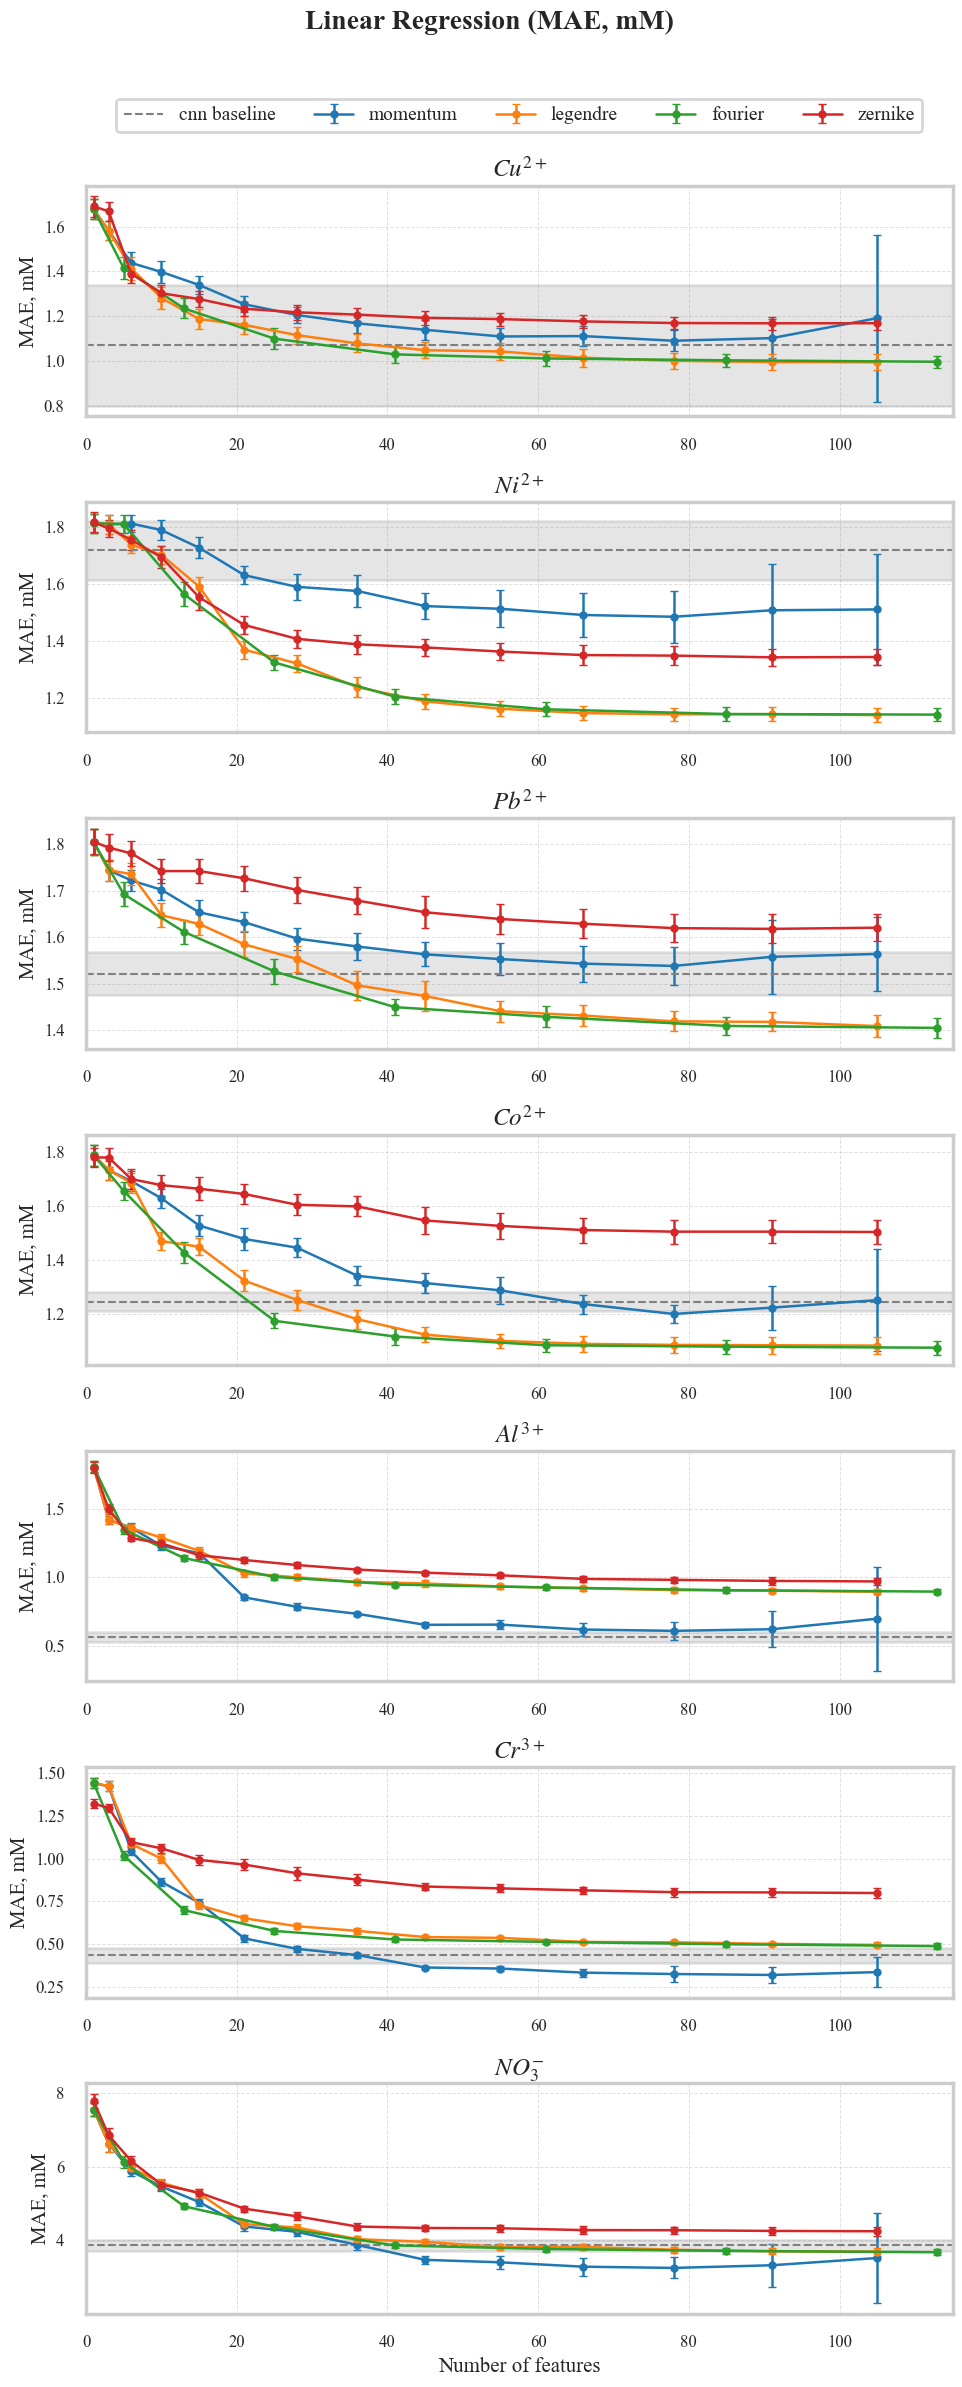

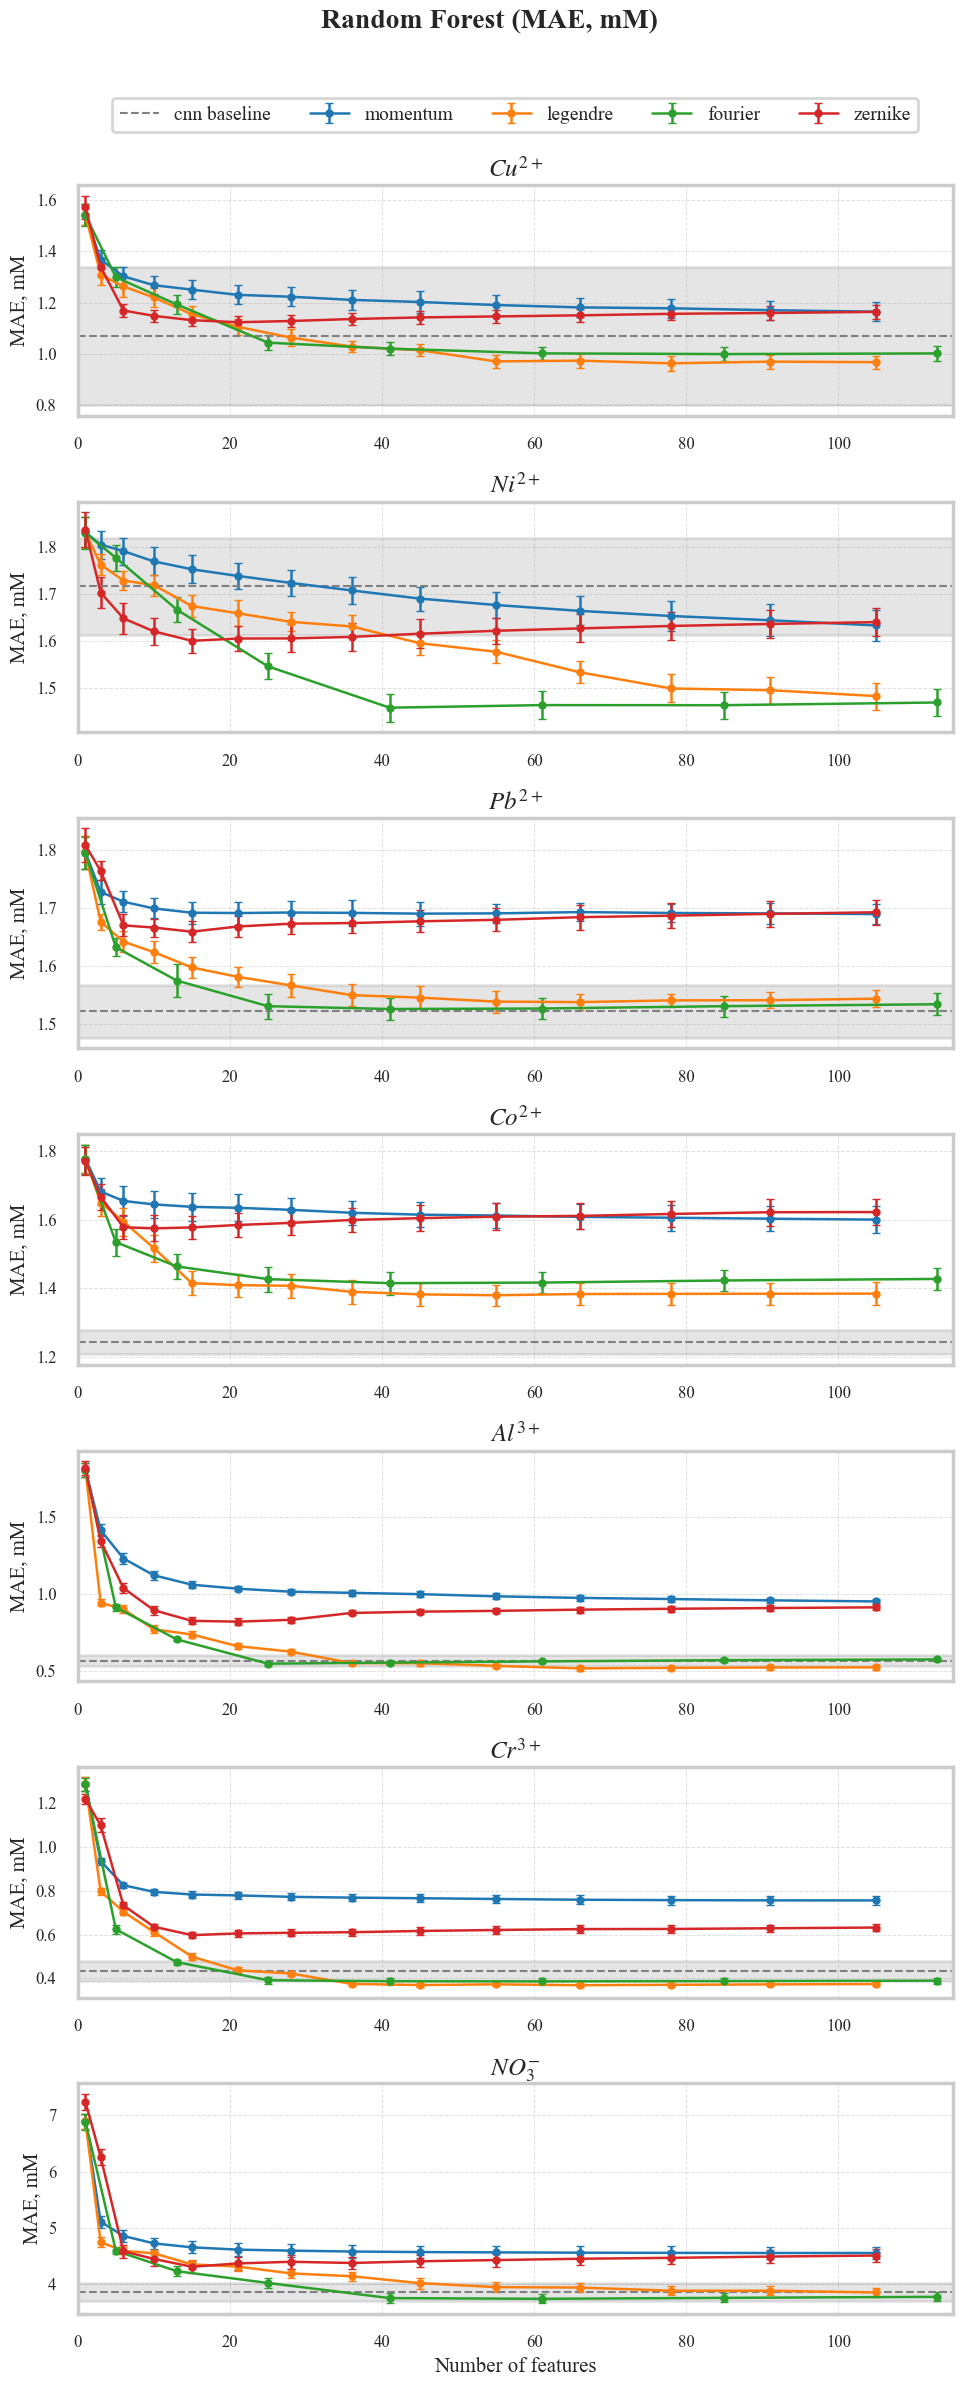

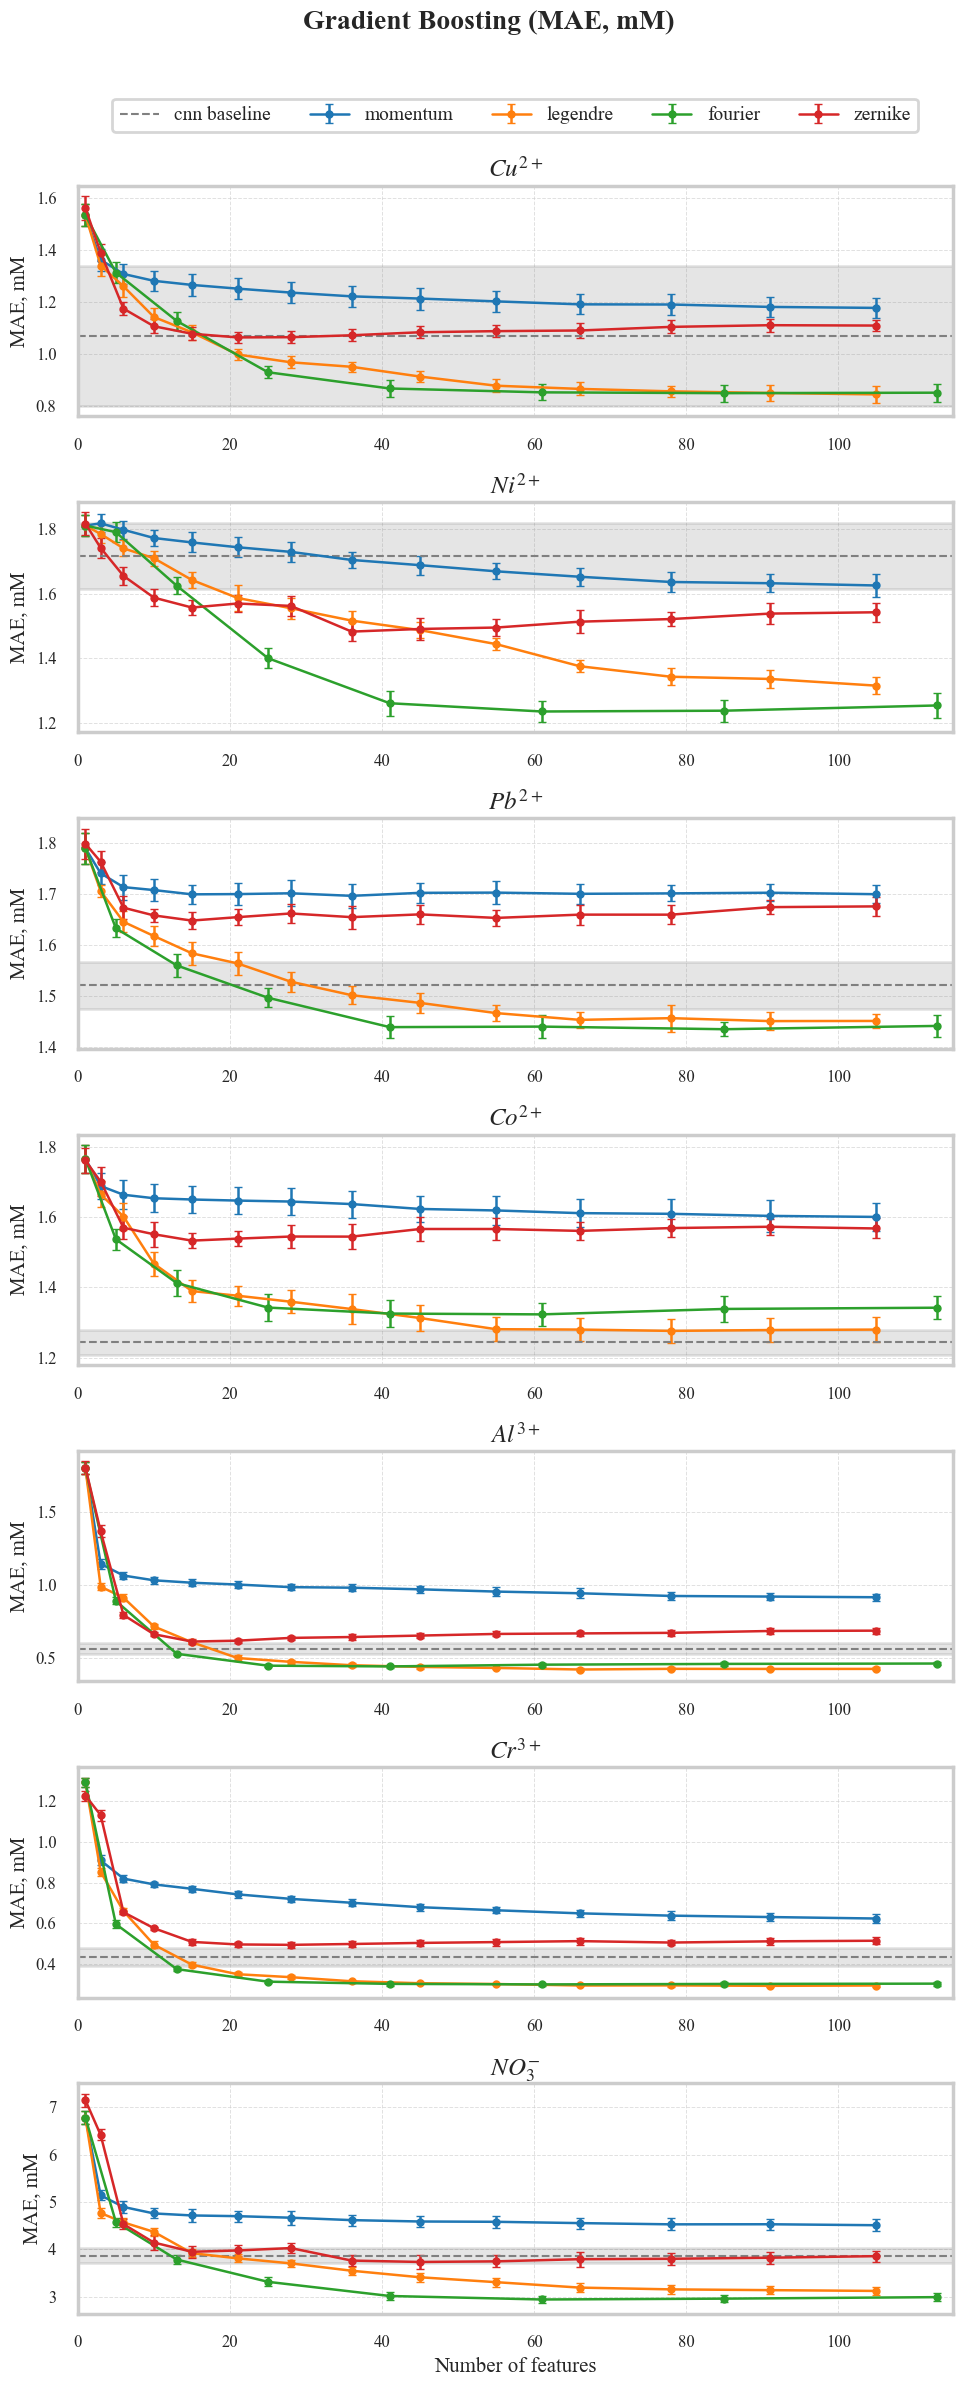

In [32]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# ==================================================
# SELECT METRIC HERE
# ==================================================
METRIC = "MAE"      # "MAE", "RMSE", "R2"

# ==================================================
# SEABORN PRESETS
# ==================================================
# sns.set_theme(style="whitegrid", context="poster")
# sns.set_theme(style="whitegrid", context="paper")

# ==================================================
# GLOBAL STYLE
# ==================================================
mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["mathtext.fontset"] = "stix"

mpl.rcParams["font.size"] = 14
mpl.rcParams["axes.titlesize"] = 18
mpl.rcParams["axes.labelsize"] = 15
mpl.rcParams["legend.fontsize"] = 14
mpl.rcParams["xtick.labelsize"] = 12
mpl.rcParams["ytick.labelsize"] = 12

# ==================================================
# AXIS LABELS BY METRIC
# ==================================================
metric_ylabel = {
    "MAE": "MAE, mM",
    "RMSE": "RMSE, mM",
    "R2": r"$R^{2}$"
}

# ==================================================
# SETTINGS
# ==================================================
XMIN, XMAX = 0, 115

models = {
    "LR": "Linear Regression",
    "RF": "Random Forest",
    "GB": "Gradient Boosting",
    # "MLP": "Multilayer Perceptron"
}

momenta = ["momentum", "legendre", "fourier", "zernike"]

ions = ["Cu", "Ni", "Pb", "Co", "Al", "Cr", "NO3"]

ion_titles = {
    "Cu":  r"$Cu^{2+}$",
    "Ni":  r"$Ni^{2+}$",
    "Pb":  r"$Pb^{2+}$",
    "Co":  r"$Co^{2+}$",
    "Al":  r"$Al^{3+}$",
    "Cr":  r"$Cr^{3+}$",
    "NO3": r"$NO_{3}^{-}$"
}

colors = {
    "momentum": "#1f77b4",
    "legendre": "#ff7f0e",
    "fourier":  "#2ca02c",
    "zernike":  "#d62728"
}

# ==================================================
# LOAD DATA
# ==================================================
with open(RESULTS_PATH, "r") as f:
    results = json.load(f)

with open(BASELINE_PATH, "r") as f:
    baseline = json.load(f)

# ==================================================
# PLOT
# ==================================================
for model_key, model_title in models.items():

    if model_key not in results:
        continue

    fig, axes = plt.subplots(
        nrows=7,
        ncols=1,
        figsize=(10, 24),
        sharex=True
    )

    fig.suptitle(
        f"{model_title} ({metric_ylabel[METRIC]})",
        fontsize=20,
        fontweight="bold",
        y=0.995
    )

    for i, ion in enumerate(ions):

        ax = axes[i]

        # ------------------------------------------
        # Plot curves
        # ------------------------------------------
        for mom in momenta:

            if ion not in results[model_key][mom]:
                continue

            xs, ys, errs = [], [], []

            feature_keys = sorted(
                results[model_key][mom][ion].keys(),
                key=lambda x: int(x)
            )

            for n_feat in feature_keys:

                vals = np.array(
                    results[model_key][mom][ion][n_feat][METRIC]
                )

                xs.append(int(n_feat))
                ys.append(np.mean(vals))
                errs.append(np.std(vals))

            if len(xs) == 0:
                continue

            ax.errorbar(
                xs,
                ys,
                yerr=errs,
                marker="o",
                lw=1.8,
                ms=5,
                capsize=3,
                color=colors[mom],
                label=mom
            )

        # ------------------------------------------
        # CNN baseline
        # ------------------------------------------
        baseline_vals = np.array(baseline[ion][METRIC])

        baseline_mean = np.mean(baseline_vals)
        baseline_std  = np.std(baseline_vals)

        ax.axhline(
            baseline_mean,
            color="gray",
            linestyle="--",
            linewidth=1.5,
            label="cnn baseline"
        )

        ax.fill_between(
            [XMIN, XMAX],
            baseline_mean - baseline_std,
            baseline_mean + baseline_std,
            color="gray",
            alpha=0.20
        )

        # ------------------------------------------
        # Axes / grid
        # ------------------------------------------
        ax.set_xlim(XMIN, XMAX)

        ax.grid(
            which="major",
            axis="both",
            linestyle="--",
            linewidth=0.7,
            alpha=0.6
        )

        # Optional useful limits for R2
        if METRIC == "R2":
            ax.set_ylim(0, 1.05)

        ax.set_title(ion_titles[ion], pad=6)
        ax.set_ylabel(metric_ylabel[METRIC])

        # x labels on every subplot
        ax.tick_params(axis="x", labelbottom=True)

        # legend only first subplot
        if i == 0:
            ax.legend(
                ncol=5,
                loc="upper center",
                bbox_to_anchor=(0.5, 1.42),
                frameon=True
            )

    axes[-1].set_xlabel("Number of features")

    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

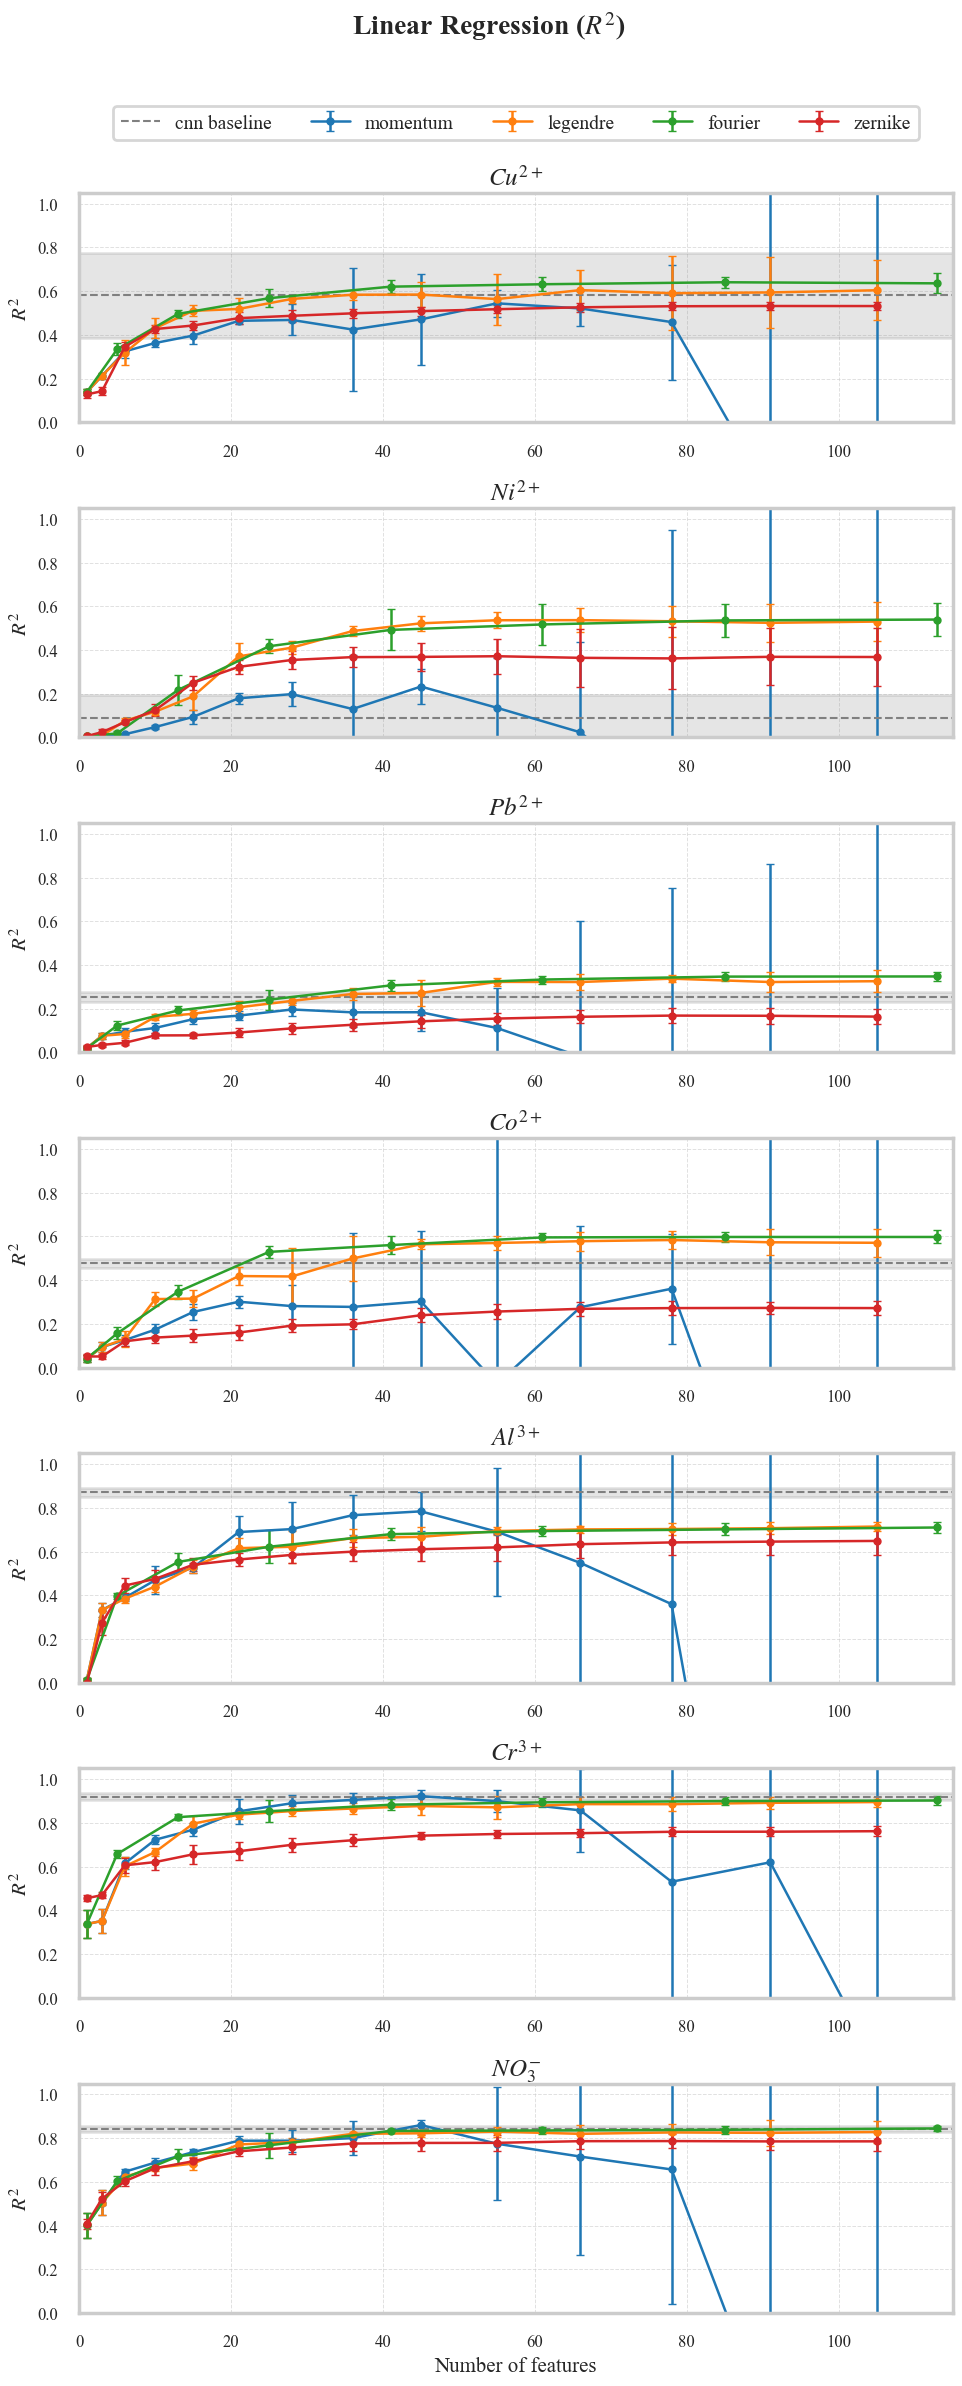

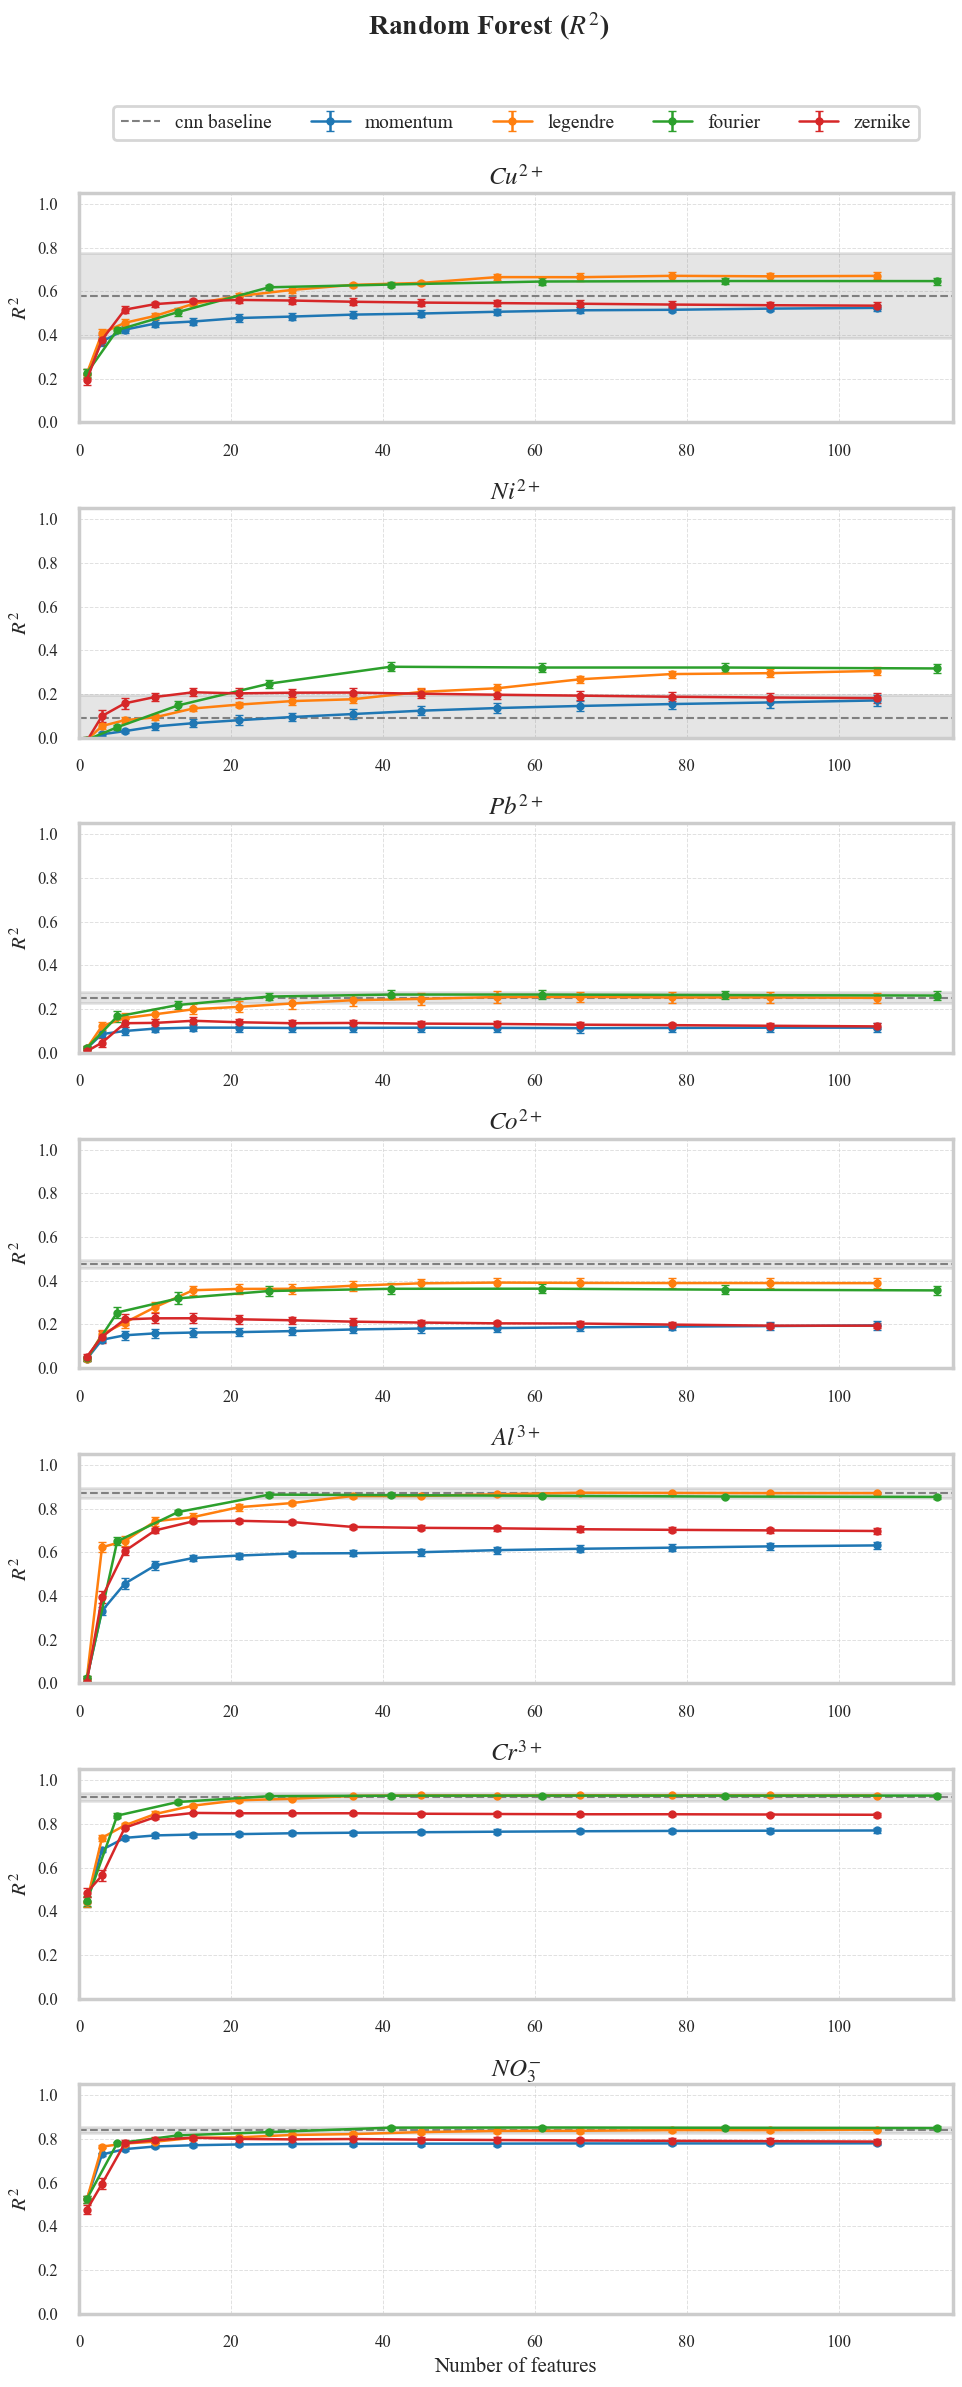

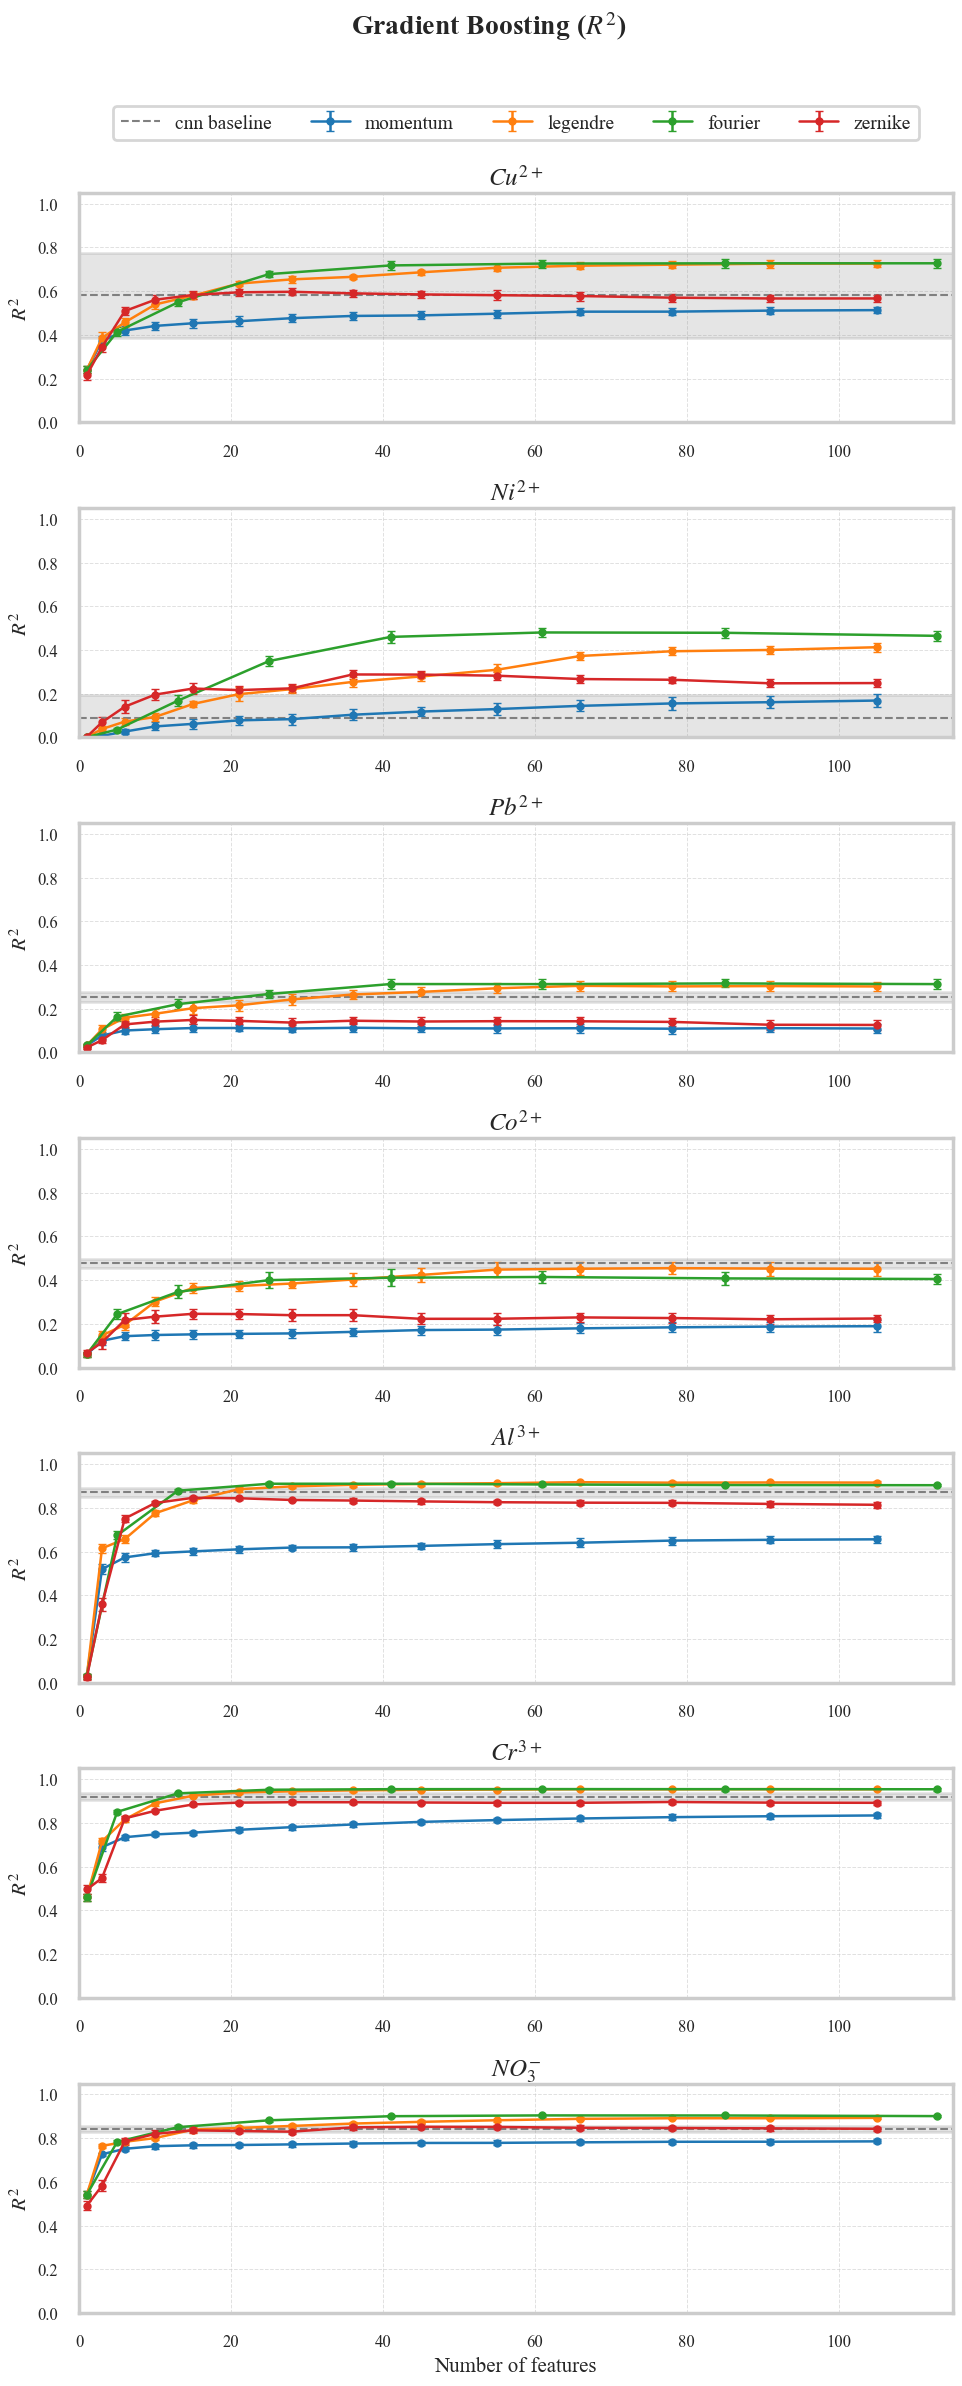

In [31]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# ==================================================
# SELECT METRIC HERE
# ==================================================
METRIC = "R2"      # "MAE", "RMSE", "R2"

# ==================================================
# SEABORN PRESETS
# ==================================================
# sns.set_theme(style="whitegrid", context="poster")
# sns.set_theme(style="whitegrid", context="paper")

# ==================================================
# GLOBAL STYLE
# ==================================================
mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["mathtext.fontset"] = "stix"

mpl.rcParams["font.size"] = 14
mpl.rcParams["axes.titlesize"] = 18
mpl.rcParams["axes.labelsize"] = 15
mpl.rcParams["legend.fontsize"] = 14
mpl.rcParams["xtick.labelsize"] = 12
mpl.rcParams["ytick.labelsize"] = 12

# ==================================================
# AXIS LABELS BY METRIC
# ==================================================
metric_ylabel = {
    "MAE": "MAE, mM",
    "RMSE": "RMSE, mM",
    "R2": r"$R^{2}$"
}

# ==================================================
# SETTINGS
# ==================================================
XMIN, XMAX = 0, 115

models = {
    "LR": "Linear Regression",
    "RF": "Random Forest",
    "GB": "Gradient Boosting",
    # "MLP": "Multilayer Perceptron"
}

momenta = ["momentum", "legendre", "fourier", "zernike"]

ions = ["Cu", "Ni", "Pb", "Co", "Al", "Cr", "NO3"]

ion_titles = {
    "Cu":  r"$Cu^{2+}$",
    "Ni":  r"$Ni^{2+}$",
    "Pb":  r"$Pb^{2+}$",
    "Co":  r"$Co^{2+}$",
    "Al":  r"$Al^{3+}$",
    "Cr":  r"$Cr^{3+}$",
    "NO3": r"$NO_{3}^{-}$"
}

colors = {
    "momentum": "#1f77b4",
    "legendre": "#ff7f0e",
    "fourier":  "#2ca02c",
    "zernike":  "#d62728"
}

# ==================================================
# LOAD DATA
# ==================================================
with open(RESULTS_PATH, "r") as f:
    results = json.load(f)

with open(BASELINE_PATH, "r") as f:
    baseline = json.load(f)

# ==================================================
# PLOT
# ==================================================
for model_key, model_title in models.items():

    if model_key not in results:
        continue

    fig, axes = plt.subplots(
        nrows=7,
        ncols=1,
        figsize=(10, 24),
        sharex=True
    )

    fig.suptitle(
        f"{model_title} ({metric_ylabel[METRIC]})",
        fontsize=20,
        fontweight="bold",
        y=0.995
    )

    for i, ion in enumerate(ions):

        ax = axes[i]

        # ------------------------------------------
        # Plot curves
        # ------------------------------------------
        for mom in momenta:

            if ion not in results[model_key][mom]:
                continue

            xs, ys, errs = [], [], []

            feature_keys = sorted(
                results[model_key][mom][ion].keys(),
                key=lambda x: int(x)
            )

            for n_feat in feature_keys:

                vals = np.array(
                    results[model_key][mom][ion][n_feat][METRIC]
                )

                xs.append(int(n_feat))
                ys.append(np.mean(vals))
                errs.append(np.std(vals))

            if len(xs) == 0:
                continue

            ax.errorbar(
                xs,
                ys,
                yerr=errs,
                marker="o",
                lw=1.8,
                ms=5,
                capsize=3,
                color=colors[mom],
                label=mom
            )

        # ------------------------------------------
        # CNN baseline
        # ------------------------------------------
        baseline_vals = np.array(baseline[ion][METRIC])

        baseline_mean = np.mean(baseline_vals)
        baseline_std  = np.std(baseline_vals)

        ax.axhline(
            baseline_mean,
            color="gray",
            linestyle="--",
            linewidth=1.5,
            label="cnn baseline"
        )

        ax.fill_between(
            [XMIN, XMAX],
            baseline_mean - baseline_std,
            baseline_mean + baseline_std,
            color="gray",
            alpha=0.20
        )

        # ------------------------------------------
        # Axes / grid
        # ------------------------------------------
        ax.set_xlim(XMIN, XMAX)

        ax.grid(
            which="major",
            axis="both",
            linestyle="--",
            linewidth=0.7,
            alpha=0.6
        )

        # Optional useful limits for R2
        if METRIC == "R2":
            ax.set_ylim(0, 1.05)

        ax.set_title(ion_titles[ion], pad=6)
        ax.set_ylabel(metric_ylabel[METRIC])

        # x labels on every subplot
        ax.tick_params(axis="x", labelbottom=True)

        # legend only first subplot
        if i == 0:
            ax.legend(
                ncol=5,
                loc="upper center",
                bbox_to_anchor=(0.5, 1.42),
                frameon=True
            )

    axes[-1].set_xlabel("Number of features")

    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()